# Adult Income Classification

A supervised learning notebook for predicting whether income exceeds 50K using preprocessing, model comparison, learning curves, feature selection, and hyperparameter tuning.


### Cell 1 – Imports  
Import required libraries for data handling, preprocessing, and modeling.

In [1]:
# Cell 1: Imports

import pandas as pd
import numpy as np

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Cell 2 – Load dataset  
Load the Adult Income dataset and show its initial shape and first rows.

In [2]:
# Cell 2: Load dataset

file_path = r"data/adult.csv"

df = pd.read_csv(file_path)

print("Initial shape:", df.shape)
display(df.head())

Initial shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### Cell 3 – Define problem and target  
Define the target column, problem type, and list all feature columns.

In [3]:
# Cell 3: Define problem and target

target_col = "income"
feature_cols = df.columns
problem_type = "binary_classification"  

print("Target column:", target_col)
print("Number of feature columns:", len(feature_cols))
print("Problem type:", problem_type)
print("Feature columns:")
print(feature_cols)

Target column: income
Number of feature columns: 15
Problem type: binary_classification
Feature columns:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [4]:
# Cell 4: Inspect structure and data types

print("DataFrame info:\n")
df.info()

print("\nBasic statistics for numeric columns:\n")
display(df.describe())

print("\nBasic statistics for all columns (including categoricals):\n")
display(df.describe(include="all"))

DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Basic statistics for numeric columns:



,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Basic statistics for all columns (including categoricals):



,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### Cell 5 – Clean string formatting  
Strip leading and trailing spaces from all string columns and preview unique values.

In [5]:
# Cell 5: Handle basic formatting issues (strip spaces from string columns)

string_cols = df.select_dtypes(include=["object"]).columns
print("String columns:", list(string_cols))

# Strip leading/trailing spaces in all string columns
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())

print("\nSample unique values after stripping spaces:")
for col in string_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10])  # show first 10 unique values

String columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

Sample unique values after stripping spaces:

Column: workclass
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']

Column: education
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm']

Column: marital.status
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']

Column: occupation
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales']

Column: relationship
['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']

Column: race
['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']

Column: sex
['Female' 'Male']

Column: native.country

### Cell 6 – Handle missing values  
Convert '?' to NaN and summarize missing values by count and percentage for each column.

In [6]:
# Cell 6: Make missing values explicit and inspect them

# In the Adult dataset, missing values are typically written as '?'
df.replace("?", np.nan, inplace=True)

missing_counts = df.isna().sum()
missing_percent = missing_counts / len(df) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent.round(2)
})

print("Missing values per column:\n")
display(missing_summary)

Missing values per column:



,missing_count,missing_percent
age,0,0.00
workclass,1836,5.64
fnlwgt,0,0.00
education,0,0.00
education.num,0,0.00
marital.status,0,0.00
occupation,1843,5.66
relationship,0,0.00
race,0,0.00
sex,0,0.00


### Cell 7 – Check and remove duplicates  
Detect duplicated rows, remove them, and show the updated dataset shape.

In [7]:
# Cell 7: Step 5 - Check for duplicate rows (no changes yet)

duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows in the dataset:", num_duplicates)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows in the dataset: 24
Shape after dropping duplicates: (32537, 15)


### Cell 8 – Numeric sanity checks  
Summarize numeric features, count negative values, and conclude there are no obvious problematic outliers.

In [8]:
# Cell 8: Step 6 - Check for invalid or extreme values in numeric features (no changes yet)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric columns:", list(numeric_cols))

print("\nSummary statistics for numeric columns:\n")
display(df[numeric_cols].describe())

# Quick check: count negative values in numeric columns
print("\nNumber of negative values per numeric column:")
print((df[numeric_cols] < 0).sum())

print(
    "\nConclusion: numeric ranges look reasonable for this dataset,\n "
    "no obvious invalid or problematic outliers at this stage. "
)

Numeric columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Summary statistics for numeric columns:



,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Number of negative values per numeric column:
age               0
fnlwgt            0
education.num     0
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64

Conclusion: numeric ranges look reasonable for this dataset,
 no obvious invalid or problematic outliers at this stage. 


### Cell 9 – Create features and split data  
Separate features and encoded target, then perform a stratified train–test split.

In [9]:
# Cell 9: Step 7 - Create features/target and split into train and test sets

# Separate features and target
X = df.drop(columns=[target_col])

# Encode target as 0 and 1
y = df[target_col].map({"<=50K": 0, ">50K": 1})

print("Target encoding value counts:")
print(y.value_counts())

# Stratified train-test split to keep class distribution similar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShapes after split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Target encoding value counts:
income
0    24698
1     7839
Name: count, dtype: int64

Shapes after split:
X_train: (26029, 14)
X_test: (6508, 14)
y_train: (26029,)
y_test: (6508,)


### Cell 10 – Define preprocessing pipeline  
Identify numeric and categorical features and build a ColumnTransformer with imputation, scaling, and one-hot encoding.

In [10]:
# Cell 10: Step 8 - Set up encoding for categorical features (and basic imputation)

# Identify categorical and numeric feature columns from training data
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical: impute missing with most frequent, then one hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ColumnTransformer that applies the right transformer to each group of columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Numeric features: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


In [11]:
# Cell 11: Step 10 - Check class imbalance in the target (no balancing yet)

print("Class distribution in the full dataset (encoded target):")
print(y.value_counts())

print("\nClass distribution as percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Class distribution in the full dataset (encoded target):
income
0    24698
1     7839
Name: count, dtype: int64

Class distribution as percentages:
income
0    75.91
1    24.09
Name: proportion, dtype: float64


In [12]:
# Cell 12: Step 11 - Check for constant or near-constant features (no changes yet)

nunique_per_col = X.nunique()
constant_features = nunique_per_col[nunique_per_col == 1]

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("\nConstant features:")
    print(constant_features)

print("\nNumber of unique values per feature (smallest 10):")
print(nunique_per_col.sort_values().head(10))

Number of constant features: 0

Number of unique values per feature (smallest 10):
sex                2
race               5
relationship       6
marital.status     7
workclass          8
occupation        14
education         16
education.num     16
native.country    41
age               73
dtype: int64


In [13]:
# Cell 13: Step 12 - Quick checks for obvious data leakage (no changes yet)

# 1. Check if any feature column is identical to the target
identical_to_target = []
for col in X.columns:
    if (df[col].astype(str) == df[target_col].astype(str)).all():
        identical_to_target.append(col)

print("Feature columns identical to target:", identical_to_target)

# 2. Correlation between numeric features and encoded target
numeric_cols_full = X.select_dtypes(include=[np.number]).columns

if len(numeric_cols_full) > 0:
    corr_with_target = df[numeric_cols_full].corrwith(y)
    print("\nCorrelation of numeric features with the target:")
    print(corr_with_target.sort_values(ascending=False))
else:
    print("\nNo numeric feature columns found for correlation check.")

Feature columns identical to target: []

Correlation of numeric features with the target:
education.num     0.335272
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
capital.loss      0.150501
fnlwgt           -0.009502
dtype: float64


### Cell 15 – Visualization setup  
Import plotting libraries and set a basic Seaborn style for visualizations.

In [15]:
# Cell 15: Imports for visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

### Cell 16 – Target distribution plot  
Plot the class distribution of the income target variable.

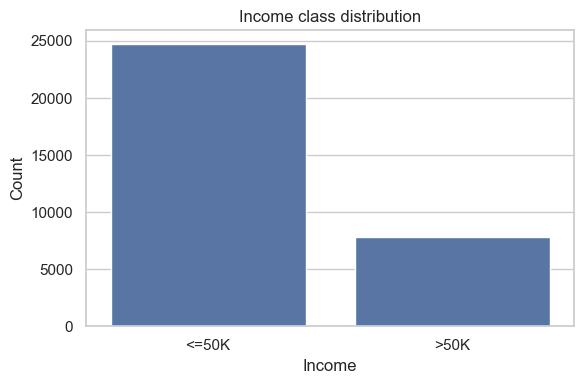

In [16]:
# Cell 16: Visualize target class distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_col])
plt.title("Income class distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Cell 17 – Histograms of numeric features  
Draw histograms for all numeric features to view their distributions.

In [17]:
# Cell 17: Histograms of numeric features

numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric columns:", list(numeric_cols))

df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of numeric features", y=1.02)
plt.tight_layout()
plt.show()

Numeric columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


### Cell 18 – Boxplots of numeric features  
Plot boxplots for numeric features to visually inspect spread and potential outliers.

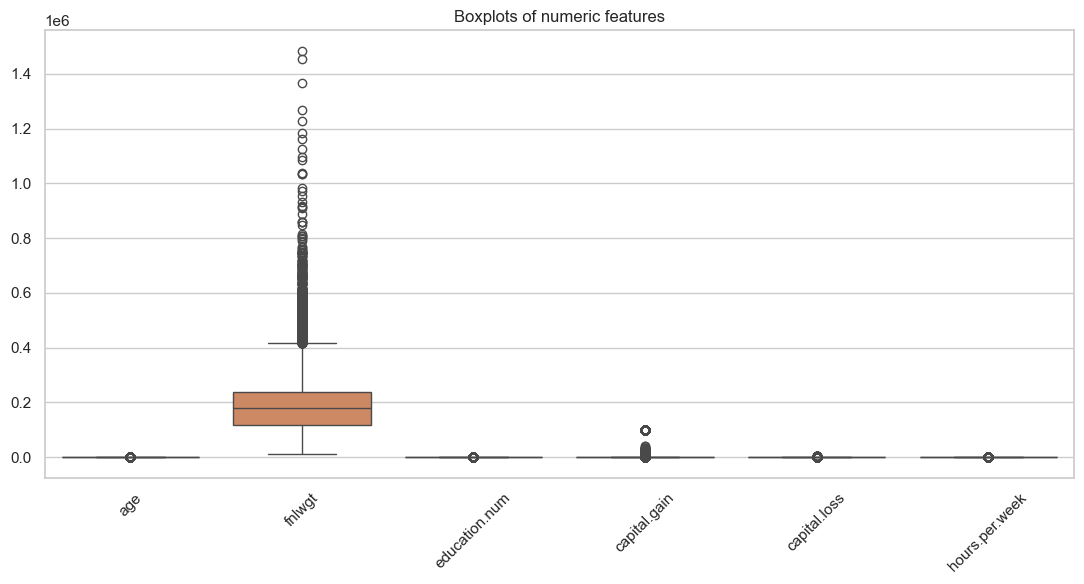

In [18]:
# Cell 18: Boxplots of numeric features

plt.figure(figsize=(11, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of numeric features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cell 19 – Categorical feature distributions  
Plot count charts for selected categorical features to understand their frequency patterns.

Categorical features plotted: ['workclass', 'education', 'occupation']


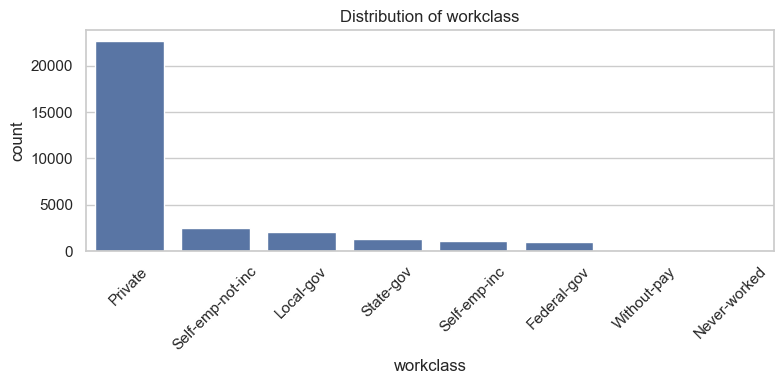

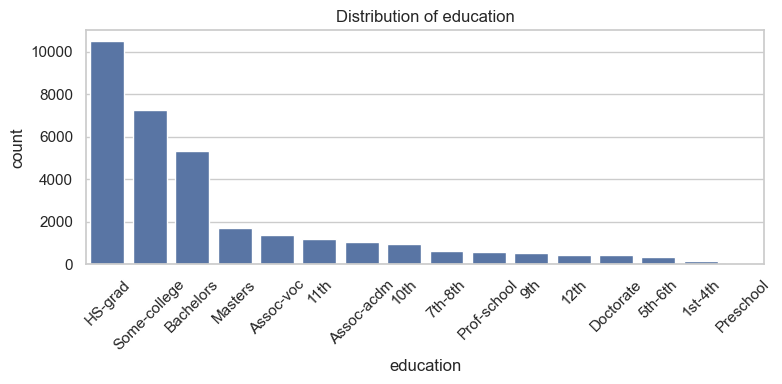

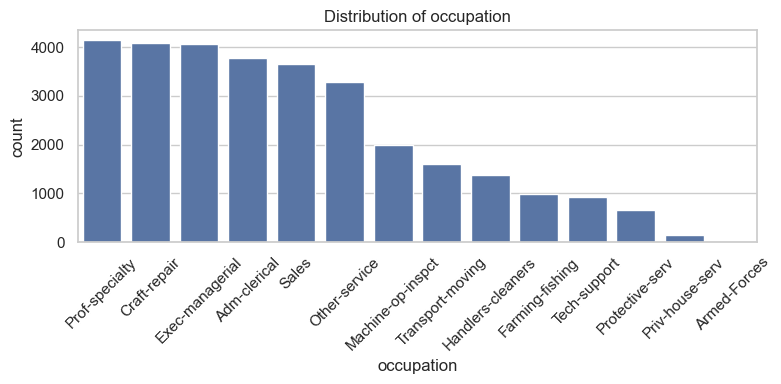

In [19]:
# Cell 19: Distribution of selected categorical features

categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = [c for c in categorical_cols if c != target_col]

cat_to_plot = [c for c in ["workclass", "education", "marital-status", "occupation"] if c in categorical_cols]
print("Categorical features plotted:", cat_to_plot)

for col in cat_to_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Cell 20 – Income distribution by sex  
Visualize how income classes are distributed across the sex categories.

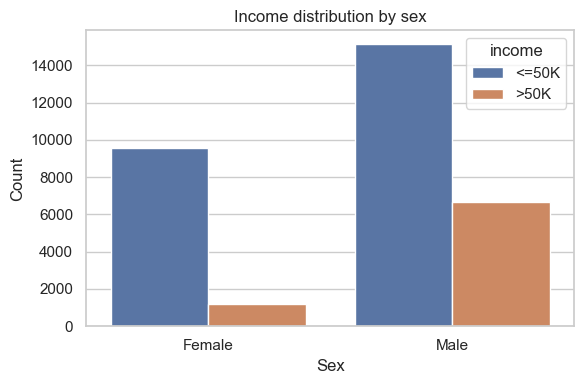

In [20]:
# Cell 20: Income distribution by sex

if "sex" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="sex", hue=target_col)
    plt.title("Income distribution by sex")
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Cell 20 – Income distribution by sex  
Visualize how income classes are distributed across the sex categories.

In [21]:
# Cell 21: Correlation heatmap for numeric features

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation matrix of numeric features")
    plt.tight_layout()
    plt.show()

### Cell 22 – Apply preprocessing  
Fit the preprocessing pipeline on the training data and transform both train and test sets.

In [22]:
# Cell 22: Apply preprocessing to train and test sets

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (26029, 104)
X_test_processed shape: (6508, 104)


### Cell 23 – Baseline Logistic Regression  
Train a baseline Logistic Regression model on the processed data and print train and test accuracy.

In [23]:
# Cell 23: Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_processed, y_train)

print("Logistic Regression training accuracy:", log_reg.score(X_train_processed, y_train))
print("Logistic Regression test accuracy:", log_reg.score(X_test_processed, y_test))

Logistic Regression training accuracy: 0.8518959621960122
Logistic Regression test accuracy: 0.8501843884449908


### Cell 24 – Baseline Random Forest  
Train a baseline Random Forest classifier and print train and test accuracy.

In [24]:
# Cell 24: Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_processed, y_train)

print("Random Forest training accuracy:", rf_clf.score(X_train_processed, y_train))
print("Random Forest test accuracy:", rf_clf.score(X_test_processed, y_test))

Random Forest training accuracy: 0.9999615813131507
Random Forest test accuracy: 0.8466502765826674


### Cell 25 – Baseline KNN  
Train a baseline KNN classifier and print train and test accuracy.

In [25]:
# Cell 25: KNN model

from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_processed, y_train)

print("KNN training accuracy:", knn_clf.score(X_train_processed, y_train))
print("KNN test accuracy:", knn_clf.score(X_test_processed, y_test))

KNN training accuracy: 0.8848976141995467
KNN test accuracy: 0.8274431468961279


### Cell 26 – Learning curve helper  
Import learning_curve and define a helper function to plot learning curves for a given model.

In [26]:
# Cell 26: Import learning_curve and define a helper function

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

    plt.plot(train_sizes, val_mean, marker="s", label="Validation score")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(title)
    plt.xlabel("Training set size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [27]:
# Cell 27: Learning curve for Logistic Regression

plot_learning_curve(
    log_reg,
    X_train_processed,
    y_train,
    title="Learning Curve - Logistic Regression"
)

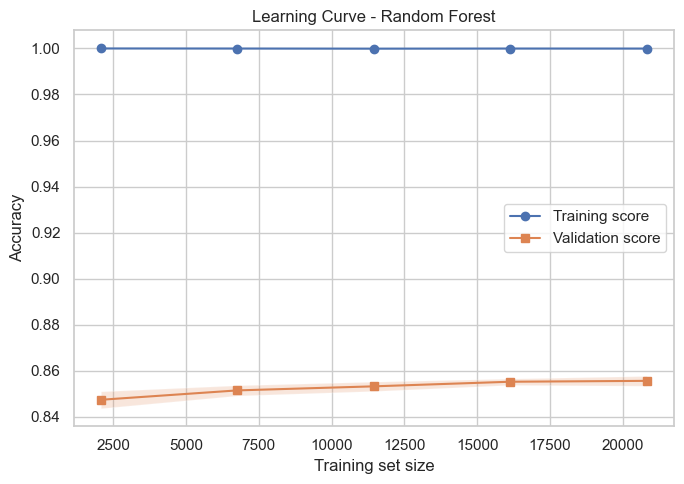

In [28]:
# Cell 28: Learning curve for Random Forest

plot_learning_curve(
    rf_clf,
    X_train_processed,
    y_train,
    title="Learning Curve - Random Forest"
)

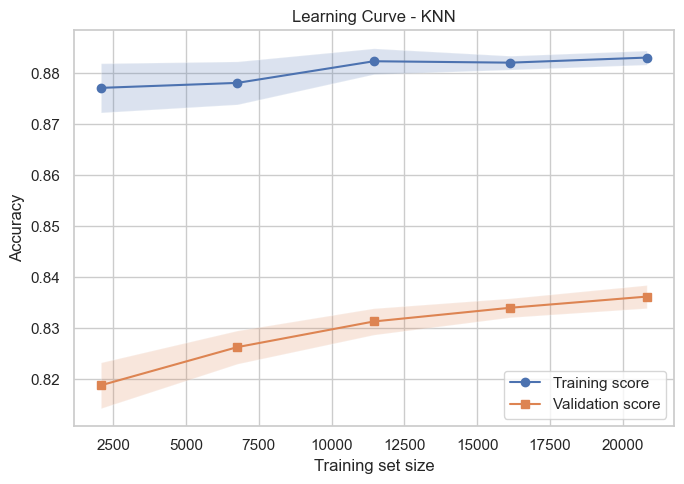

In [29]:
# Cell 29: Learning curve for KNN

plot_learning_curve(
    knn_clf,
    X_train_processed,
    y_train,
    title="Learning Curve - KNN"
)

### Cell 30 – Evaluation metrics helper  
Import evaluation metrics and define a helper function to compute and print multiple scores for a model.

In [30]:
# Cell 30: Metrics and evaluation helper

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name} performance on test set:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  ROC AUC  : {auc:.4f}")

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    }

### Cell 31 – Baseline model comparison  
Evaluate all three baseline models on the test set and summarize their metrics in a table.

In [31]:
# Cell 31: Baseline performance comparison for Logistic Regression, Random Forest, and KNN

results_baseline = []

results_baseline.append(evaluate_model("Logistic Regression", log_reg, X_test_processed, y_test))
results_baseline.append(evaluate_model("Random Forest", rf_clf, X_test_processed, y_test))
results_baseline.append(evaluate_model("KNN", knn_clf, X_test_processed, y_test))

baseline_df = pd.DataFrame(results_baseline)
print("\nBaseline comparison table:")
display(baseline_df)


Logistic Regression performance on test set:
  Accuracy : 0.8502
  Precision: 0.7344
  Recall   : 0.5925
  F1-score : 0.6558
  ROC AUC  : 0.9004

Random Forest performance on test set:
  Accuracy : 0.8467
  Precision: 0.7149
  Recall   : 0.6046
  F1-score : 0.6551
  ROC AUC  : 0.8925

KNN performance on test set:
  Accuracy : 0.8274
  Precision: 0.6618
  Recall   : 0.5804
  F1-score : 0.6184
  ROC AUC  : 0.8510

Baseline comparison table:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.850184,0.734387,0.592474,0.655842,0.900386
1,Random Forest,0.846650,0.714932,0.604592,0.655149,0.892483
2,KNN,0.827443,0.661818,0.580357,0.618417,0.851032


### Cell 32 – Tune Logistic Regression  
Use GridSearchCV to tune the C parameter of Logistic Regression and select the best model.

In [32]:
# Cell 32: Hyperparameter tuning for Logistic Regression using GridSearchCV

from sklearn.model_selection import GridSearchCV

log_reg_tuned = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10]
}

grid_logreg = GridSearchCV(
    estimator=log_reg_tuned,
    param_grid=param_grid_logreg,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_logreg.fit(X_train_processed, y_train)

print("Best parameters for Logistic Regression:", grid_logreg.best_params_)
print("Best CV accuracy for Logistic Regression:", grid_logreg.best_score_)

best_log_reg = grid_logreg.best_estimator_

Best parameters for Logistic Regression: {'C': 0.1}
Best CV accuracy for Logistic Regression: 0.8506665810490592


### Cell 33 – Tune Random Forest  
Use GridSearchCV to tune key Random Forest hyperparameters and select the best model.

In [33]:
# Cell 33: Hyperparameter tuning for Random Forest using GridSearchCV

rf_tuned = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best CV accuracy for Random Forest:", grid_rf.best_score_)

best_rf_clf = grid_rf.best_estimator_

Best parameters for Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy for Random Forest: 0.866072347616343


### Cell 34 – KNN feature selection and tuning  
Build a pipeline with SelectKBest and KNN, then use GridSearchCV to choose the best number of features and neighbors.

In [35]:
# Cell 34: Simpler KNN feature selection + hyperparameter tuning

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: feature selection + KNN
knn_pipe = Pipeline([
    ("select", SelectKBest(score_func=mutual_info_classif, k=30)),
    ("knn", KNeighborsClassifier())
])

# Small grid so it is not too slow
param_grid_knn = {
    "select__k": [20, 40, 60],     # number of selected features
    "knn__n_neighbors": [3, 5, 7]  # neighbors to try
}

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_processed, y_train)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Best CV accuracy for KNN:", grid_knn.best_score_)

best_knn_pipe = grid_knn.best_estimator_


<python-site-packages>/sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
<python-site-packages>/sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
<python-site-packages>/sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
<python-site-packages>/sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
<python-site-packages>/sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering me

Best parameters for KNN: {'knn__n_neighbors': 7, 'select__k': 20}
Best CV accuracy for KNN: 0.8396020035996299


### Cell 35 – Tuned models comparison  
Evaluate the tuned versions of all three models on the test set and display their metrics in a comparison table.

In [36]:
# Cell 35: Evaluate tuned models on test set

results_tuned = []

# Logistic Regression (tuned)
results_tuned.append(
    evaluate_model("Logistic Regression (tuned)", best_log_reg, X_test_processed, y_test)
)

# Random Forest (tuned)
results_tuned.append(
    evaluate_model("Random Forest (tuned)", best_rf_clf, X_test_processed, y_test)
)

# KNN (tuned + feature selection)
results_tuned.append(
    evaluate_model("KNN (tuned + FS)", best_knn_pipe, X_test_processed, y_test)
)

tuned_df = pd.DataFrame(results_tuned)
print("\nTuned models comparison table:")
display(tuned_df)



Logistic Regression (tuned) performance on test set:
  Accuracy : 0.8505
  Precision: 0.7367
  Recall   : 0.5906
  F1-score : 0.6556
  ROC AUC  : 0.9005

Random Forest (tuned) performance on test set:
  Accuracy : 0.8551
  Precision: 0.7611
  Recall   : 0.5810
  F1-score : 0.6590
  ROC AUC  : 0.9086

KNN (tuned + FS) performance on test set:
  Accuracy : 0.8368
  Precision: 0.6841
  Recall   : 0.5995
  F1-score : 0.6390
  ROC AUC  : 0.8630

Tuned models comparison table:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (tuned),0.850492,0.736675,0.590561,0.655575,0.900474
1,Random Forest (tuned),0.855101,0.761069,0.580995,0.658951,0.908626
2,KNN (tuned + FS),0.836816,0.684134,0.599490,0.639021,0.862980
